# Lesson 1 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/1/1-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives you a function signature and a docstring stating exactly
what the function must return. Replace the `raise NotImplementedError` with
your implementation. The cell immediately after each task contains
`assert` statements that check your work.

**A failing assert is information, not a grade.** It tells you that the
behaviour does not yet match the contract. Read the assertion message, fix
the function, re-run the cell. There is no penalty for running a cell
twenty times.

The written questions are marked. They are the part of this homework that
carries the learning objective: each one asks you to *run something both
ways and explain the difference*, not to recall a fact. Answers of one
sentence will not be enough; answers of one paragraph, referring to numbers
you actually produced, will.

Every function you need has been demonstrated in `1-practice.ipynb`. Each
task names the section — `see Practice 1 §3.6` — where the relevant material
is. You should not need any other documentation, and you should not need to
search the internet. If you find yourself wanting to, the reference is
probably in the practice notebook and worth finding.

## Before you submit

**Runtime → Restart and run all must complete without error**, with every
assert passing. A notebook that only works because you ran the cells in an
unusual order is not reproducible, and reproducibility is the subject of
§4.1 of the practice notebook.

Then **File → Download → Download .ipynb**, rename the file to
`1-homework-results.ipynb`, and commit it to your fork under
`practice/1/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

Run this first. It is the same configuration cell as the practice notebook.

In [4]:
import sys

import numpy as np
import matplotlib.pyplot as plt

SEED = 20250919
rng = np.random.default_rng(SEED)

plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11
plt.rcParams["lines.linewidth"] = 2.0

print("python", sys.version.split()[0], "| numpy", np.__version__)

python 3.13.15 | numpy 2.1.3


## 2. Task 1 — Describe an array

Mechanical. Return the five attributes that describe an array's layout.

*see Practice 1 §3.2*

In [5]:
def describe_array(arr):
    """Return a dict describing the memory layout of `arr`.

    Keys, exactly these five:
        'dtype'    the element type, as a string (use str(...) on the dtype)
        'shape'    the shape, as a tuple
        'ndim'     the number of dimensions, as an int
        'size'     the total number of elements, as an int
        'nbytes'   the total number of bytes occupied by the data, as an int

    No allocation and no copying: read the attributes off `arr`.
    """
    return {
        "dtype": str(arr.dtype),
        "shape": arr.shape,
        "ndim": arr.ndim,
        "size": arr.size,
        "nbytes": arr.nbytes,
    }

In [8]:
_result = describe_array(np.zeros((3, 4), dtype=np.float64))
assert set(_result) == {"dtype", "shape", "ndim", "size", "nbytes"}, \
    f"expected exactly those five keys, got {sorted(_result)}"
assert _result["shape"] == (3, 4), f"shape wrong: {_result['shape']}"
assert _result["ndim"] == 2, f"ndim wrong: {_result['ndim']}"
assert _result["size"] == 12, f"size wrong: {_result['size']}"
assert _result["nbytes"] == 96, f"nbytes wrong: {_result['nbytes']} (12 elements x 8 bytes)"
assert "float64" in _result["dtype"], f"dtype wrong: {_result['dtype']}"

_int_result = describe_array(np.arange(10, dtype=np.int32))
assert _int_result["nbytes"] == 40, "an int32 array of 10 elements occupies 40 bytes"
assert _int_result["ndim"] == 1

print("Task 1 passed.")

Task 1 passed.


## 3. Task 2 — A view bug, and the fix

The function below is supposed to return a copy of the middle of an array
with its values clipped to zero, leaving the caller's array untouched. It
does not. Find the defect and repair it.

Do not change the signature and do not change what the function returns —
only make it stop modifying its argument.

*see Practice 1 §3.6*

In [6]:
def zero_the_middle(arr, start, stop):
    """Return a NEW array holding arr[start:stop] with every value set to 0.

    `arr` must not be modified. The returned array must have length
    stop - start and must not share memory with `arr`.

    The body below is the broken version. Fix it.
    """
    middle = arr[start:stop] .copy()
    middle[:] = 0
    return middle

In [10]:
_original = np.arange(10)
_untouched = np.arange(10)
_returned = zero_the_middle(_original, 3, 6)

assert np.array_equal(_original, _untouched), \
    f"the argument was modified: {_original} should still be {_untouched}"
assert _returned.shape == (3,), f"wrong length: {_returned.shape}"
assert np.all(_returned == 0), f"values not zeroed: {_returned}"
assert not np.shares_memory(_returned, _original), \
    "the result still shares memory with the argument"

print("Task 2 passed.")

Task 2 passed.


## 4. Task 3 — Standardise the columns of a matrix

Applied. Subtract each column's mean and divide by each column's standard
deviation, using broadcasting rather than a loop over columns.

This is what `StandardScaler` does, and Practice 2 §9 will use the
scikit-learn object. Writing it once by hand is the point.

*see Practice 1 §3.7 and §3.8*

In [7]:
def standardise_columns(matrix):
    """Return `matrix` with every column centred and scaled to unit variance.

    For each column j:  out[:, j] = (matrix[:, j] - mean_j) / sd_j

    Use the population standard deviation (NumPy's default, ddof=0).
    The result has the same shape as `matrix`. Do not modify `matrix`.
    Use broadcasting; do not write a `for` loop over the columns.
    """
    mean = matrix.mean(axis=0)
    sd = matrix.std(axis=0)
    return (matrix - mean) / sd

In [8]:
_data = np.array([[1.0, 100.0],
                  [2.0, 200.0],
                  [3.0, 300.0],
                  [4.0, 400.0]])
_before = _data.copy()
_scaled = standardise_columns(_data)

assert _scaled.shape == _data.shape, f"shape changed: {_scaled.shape}"
assert np.array_equal(_data, _before), "the input matrix was modified"
assert np.allclose(_scaled.mean(axis=0), 0.0), \
    f"columns not centred, means are {_scaled.mean(axis=0)}"
assert np.allclose(_scaled.std(axis=0), 1.0), \
    f"columns not unit variance, sds are {_scaled.std(axis=0)}"
# The two columns are the same numbers on different scales, so after
# standardising they must be identical.
assert np.allclose(_scaled[:, 0], _scaled[:, 1]), \
    "a linear rescaling of a column should standardise to the same values"

_wide = rng.normal(5.0, 3.0, size=(200, 7))
assert np.allclose(standardise_columns(_wide).mean(axis=0), 0.0, atol=1e-12)
assert np.allclose(standardise_columns(_wide).std(axis=0), 1.0)

print("Task 3 passed.")

Task 3 passed.


## 5. Task 4 — Reductions along an axis

Mechanical, but the axis argument is the thing being tested. Read the
docstring carefully: two of these collapse rows and two collapse columns.

*see Practice 1 §3.8*

In [9]:
def axis_summary(matrix):
    """Return a dict of four reductions of a 2-D array.

    Keys and contents:
        'per_column_mean'  one value per COLUMN, shape (n_columns,)
        'per_row_sum'      one value per ROW,    shape (n_rows,)
        'per_row_max'      one value per ROW,    shape (n_rows,)
        'grand_total'      the sum of every element, a scalar float

    Return NumPy arrays for the first three and a Python/NumPy float for
    the last.
    """
    return {
        "per_column_mean": matrix.mean(axis=0),
        "per_row_sum": matrix.sum(axis=1),
        "per_row_max": matrix.max(axis=1),
        "grand_total": matrix.sum(),
    }

In [10]:
_grid = np.array([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])
_summary = axis_summary(_grid)

assert _summary["per_column_mean"].shape == (3,), \
    f"per_column_mean should have one value per column: {_summary['per_column_mean'].shape}"
assert np.allclose(_summary["per_column_mean"], [2.5, 3.5, 4.5])
assert _summary["per_row_sum"].shape == (2,), \
    f"per_row_sum should have one value per row: {_summary['per_row_sum'].shape}"
assert np.allclose(_summary["per_row_sum"], [6.0, 15.0])
assert np.allclose(_summary["per_row_max"], [3.0, 6.0])
assert np.isclose(_summary["grand_total"], 21.0)

# A non-square array catches an axis swapped by accident.
_tall = rng.normal(size=(50, 4))
_tall_summary = axis_summary(_tall)
assert _tall_summary["per_column_mean"].shape == (4,)
assert _tall_summary["per_row_sum"].shape == (50,)

print("Task 4 passed.")

Task 4 passed.


### Question 1 — the axis argument

Take the `(50, 4)` array `_tall` from the cell above. Compute `_tall.sum()`,
`_tall.sum(axis=0)` and `_tall.sum(axis=1)`, and print the shape of each.

Explain, in your own words, **why `axis=0` produces four numbers and not
fifty**, given that the array has fifty rows. Then state which of the three
you would use to answer the question "what is the average value of each
feature across all samples", and why.

In [11]:
_total = _tall.sum()
_sum0 = _tall.sum(axis=0)
_sum1 = _tall.sum(axis=1)

print("_tall.sum()        ->", _total, "shape:", np.shape(_total))
print("_tall.sum(axis=0)  ->", _sum0)
print("  shape:", _sum0.shape)
print("_tall.sum(axis=1)  -> (перші 5)", _sum1[:5])
print("  shape:", _sum1.shape)

_tall.sum()        -> -9.792221026356906 shape: ()
_tall.sum(axis=0)  -> [-8.02177989 -0.81004707  8.21145867 -9.17185273]
  shape: (4,)
_tall.sum(axis=1)  -> (перші 5) [-0.50510624 -2.09015697  0.15802573  0.22961949 -0.40134908]
  shape: (50,)


Обчислення дали такі результати: _tall.sum() = -9.79 і має форму () (це скаляр, узагалі без вимірів — просто одне число). _tall.sum(axis=0) дав 4 числа: [-8.02, -0.81, 8.21, -9.17], форма (4,). _tall.sum(axis=1) дав 50 чисел (перші п'ять: -0.51, -2.09, 0.16, 0.23, -0.40), форма (50,).

Масив _tall має форму (50, 4) — 50 рядків (зразків) і 4 стовпці (ознак). Аргумент axis вказує, вздовж якого виміру відбувається згортання (тут — підсумовування). axis=0 — це вимір рядків, тож підсумовування вздовж axis=0 означає: пройти вниз по кожному стовпцю і скласти всі 50 значень у ньому. Рядки в результаті зникають ("з'їдаються" сумою), а стовпці залишаються — тому виходить лише 4 числа, по одному на кожен стовпець, а не 50. Якби ми хотіли навпаки — по одному числу на кожен рядок, — треба було б узяти axis=1: тоді зникають стовпці, а рядки лишаються, що й дає нам 50 значень.

Щоб відповісти на питання "яке середнє значення кожної ознаки по всіх зразках", потрібен саме axis=0 (в даному випадку — _tall.mean(axis=0), а не .sum(axis=0), якщо мова йде саме про середнє). Ознаки — це стовпці, зразки — це рядки. Нам потрібне одне число на кожну з 4 ознак, усереднене по всіх 50 зразках, а саме таку форму — (4,) — і дає згортання вздовж axis=0.

## 6. Task 5 — Outliers by the k-sigma rule

Applied. Generalise the practice notebook's 3σ filter to an arbitrary threshold.

*see Practice 1 §3.9 and §4.7*

In [12]:
def sigma_outliers(sample, k=3.0):
    """Flag the values of `sample` that lie more than k standard deviations
    from the sample mean.

    Use the mean and standard deviation OF THE SAMPLE itself, not assumed
    values, and NumPy's default ddof=0 for the standard deviation.

    Return a tuple (mask, values):
        mask    a boolean array, the same shape as `sample`, True where the
                value is an outlier
        values  the outlying values themselves, in their original order

    Build the mask with a vectorised comparison; do not loop.
    """
    mean = sample.mean()
    sd = sample.std()
    mask = np.abs(sample - mean) > k * sd
    values = sample[mask]
    return mask, values

In [13]:
_plain = np.array([1.0, 2.0, 3.0, 2.0, 1.0, 50.0])
_mask, _values = sigma_outliers(_plain, k=2.0)

assert _mask.dtype == bool, f"mask must be boolean, got {_mask.dtype}"
assert _mask.shape == _plain.shape, f"mask shape {_mask.shape} != sample shape {_plain.shape}"
assert _mask.sum() == 1, f"expected exactly one outlier at k=2, found {_mask.sum()}"
assert np.allclose(_values, [50.0]), f"wrong value flagged: {_values}"

# On a clean normal sample the 3-sigma rule should flag very few points.
_normal = rng.normal(0.0, 1.0, 10_000)
_normal_mask, _ = sigma_outliers(_normal, k=3.0)
_rate = _normal_mask.mean()
assert 0.0 < _rate < 0.01, \
    f"flag rate {_rate:.4f} is implausible for 3 sigma on normal data (expect ~0.0027)"

# A larger threshold can never flag more points than a smaller one.
assert sigma_outliers(_normal, k=4.0)[0].sum() <= _normal_mask.sum()

print(f"Task 5 passed. 3-sigma flag rate on 10,000 normal draws: {_rate:.4%}")

Task 5 passed. 3-sigma flag rate on 10,000 normal draws: 0.3100%


### Question 2 — the threshold is a choice

Using the 10 000-point normal sample `_normal`, run `sigma_outliers` at
`k = 1, 2, 3, 4, 5` and print the number of points flagged at each.

Then answer: the theoretical fractions outside k standard deviations of a
normal distribution are about 32 %, 4.6 %, 0.27 %, 0.0063 % and 0.000057 %.
Compare your counts with those. **At which k does the sample stop having
enough data to estimate the rate at all**, and what does that imply about
using a very large k to define an outlier?

Finally: none of the points in `_normal` is an error — they all came from
the same generator. Describe one concrete situation in which you *would* be
justified in deleting a flagged point, and say what evidence would justify
it.

In [14]:
for k in [1, 2, 3, 4, 5]:
    mask, values = sigma_outliers(_normal, k=k)
    print(f"k={k}: flagged={mask.sum()}, rate={mask.mean():.6%}")

k=1: flagged=3163, rate=31.630000%
k=2: flagged=454, rate=4.540000%
k=3: flagged=31, rate=0.310000%
k=4: flagged=2, rate=0.020000%
k=5: flagged=0, rate=0.000000%


При k=1 отримано 3163 точки (31.63%) — дуже близько до теоретичних 32%. При k=2 — 454 точки (4.54%) проти теоретичних 4.6% — теж близько. При k=3 — 31 точка (0.31%) проти теоретичних 0.27% — розходження вже помітніше, хоча порядок величини правильний. При k=4 теоретично очікується лише 0.0063% від 10 000 точок, тобто приблизно 0.63 точки — тобто теоретично ми маємо побачити або 0, або 1 точку, а не якесь стабільне число. У мене вийшло 2 точки — це вже випадковий шум, а не надійна оцінка. При k=5 теоретично очікується 0.000057% від 10 000, тобто приблизно 0.0000057 точки — по суті нуль; у вибірці справді жодної точки не позначено.

Вибірка перестає давати змогу надійно оцінити частку вже приблизно на k=4: теоретична частка настільки мала, що очікувана кількість точок у вибірці з 10 000 — менше однієї. Це означає, що результат при такому k визначається переважно випадковістю конкретної вибірки, а не справжньою частотою події. Щоб надійно оцінити частоту в 0.0063%, знадобилася б вибірка в сотні тисяч чи мільйони точок — інакше різниця між "0 знайдено" і "2 знайдено" нічого не говорить про справжню ймовірність.

Це має практичний наслідок: використання дуже великого k для визначення "викиду" на невеликій вибірці — погана ідея, бо поріг стає настільки суворим, що практично ніколи не спрацьовує, а якщо й спрацьовує, то це радше лотерея, ніж статистично обґрунтоване рішення. Такий поріг не "ловить" рідкісні аномалії надійно — він просто робить правило марним для реальних розмірів вибірки.

Жодна з точок у _normal насправді не є помилкою — усі вони згенеровані тим самим нормальним розподілом, просто деякі опинилися далеко від середнього через природну мінливість. Це нагадує, що статистичний "викид" (далека від середнього точка) і "помилка вимірювання" — різні речі, і сама лише відстань від середнього не доводить, що точка хибна.

Конкретна ситуація, коли видалення позначеної точки було б виправданим: якщо в лабораторному вимірюванні датчик зафіксував фізично неможливе значення — наприклад, вага людини "-15 кг" або температура повітря "5000°C". Доказом тут слугує не сама відстань від середнього, а зовнішня інформація — знання про фізичні межі величини, або лог обладнання, що показує збій сенсора чи помилку введення даних (наприклад, переплутані одиниці виміру, зайвий нуль при ручному введенні). Тобто виправданою підставою для видалення є не статистичне правило "3 сигми" саме по собі, а незалежний доказ того, що вимірювання не відображає реальний процес, який ми хочемо описати.



## 7. Task 6 — A NaN-aware mean, written by hand

Mechanical. Do not call `np.nanmean`; the point is to build it from the
masking tools.

*see Practice 1 §3.9 and §3.10*

In [15]:
def mean_ignoring_nan(sample):
    """Return the mean of the non-missing values of `sample`.

    Equivalent to np.nanmean, but you must implement it with np.isnan and
    boolean masking rather than calling any nan-aware NumPy reduction.

    If every value is missing, return np.nan.
    """
    mask = ~np.isnan(sample)
    if not mask.any():
        return np.nan
    return sample[mask].mean()

In [25]:
assert np.isclose(mean_ignoring_nan(np.array([1.0, 2.0, np.nan, 4.0])), 7.0 / 3.0)
assert np.isclose(mean_ignoring_nan(np.array([5.0, 5.0, 5.0])), 5.0)
assert np.isnan(mean_ignoring_nan(np.array([np.nan, np.nan]))), \
    "an all-missing sample has no mean; return np.nan"

_with_gaps = rng.normal(0.0, 1.0, 1000)
_with_gaps[rng.choice(1000, size=100, replace=False)] = np.nan
assert np.isclose(mean_ignoring_nan(_with_gaps), np.nanmean(_with_gaps)), \
    "your result should agree with np.nanmean"
assert np.isnan(_with_gaps.mean()), \
    "sanity check: the plain mean of an array containing NaN is NaN"

print("Task 6 passed.")

Task 6 passed.


## 8. Task 7 — How well does a sample know its own distribution

Applied. Draw samples of increasing size from a known normal distribution
and measure how far the estimated parameters fall from the true ones.

*see Practice 1 §4.1 and §4.6*

In [16]:
def recover_parameters(true_mu, true_sigma, sizes, generator):
    """Estimate mu and sigma from samples of several sizes.

    For each n in `sizes`, draw n values from normal(true_mu, true_sigma)
    using `generator`, and record the sample mean and the UNBIASED sample
    standard deviation (ddof=1).

    Draw the samples in the order the sizes are given, taking every sample
    from the same `generator` object, so that the result is reproducible
    for a given seed.

    Return a dict with three keys, each a NumPy array of len(sizes):
        'n'          the sample sizes, as given
        'mu_hat'     the estimated means
        'sigma_hat'  the estimated standard deviations
    """
    mu_hat = []
    sigma_hat = []
    for n in sizes:
        sample = generator.normal(true_mu, true_sigma, n)
        mu_hat.append(sample.mean())
        sigma_hat.append(sample.std(ddof=1))
    return {
        "n": np.array(sizes),
        "mu_hat": np.array(mu_hat),
        "sigma_hat": np.array(sigma_hat),
    }

In [17]:
_sizes = [10, 100, 1_000, 10_000, 100_000]
_recovered = recover_parameters(2.0, 5.0, _sizes, np.random.default_rng(0))

assert set(_recovered) == {"n", "mu_hat", "sigma_hat"}
assert len(_recovered["mu_hat"]) == len(_sizes)
assert np.array_equal(_recovered["n"], np.array(_sizes))

# Reproducible: the same seed must give the same estimates.
_again = recover_parameters(2.0, 5.0, _sizes, np.random.default_rng(0))
assert np.allclose(_recovered["mu_hat"], _again["mu_hat"]), \
    "same seed gave different answers; are you drawing from the generator you were passed?"

# The largest sample must land close to the truth.
assert abs(_recovered["mu_hat"][-1] - 2.0) < 0.1, \
    f"mu estimate from 100,000 draws is {_recovered['mu_hat'][-1]:.4f}, expected near 2.0"
assert abs(_recovered["sigma_hat"][-1] - 5.0) < 0.1, \
    f"sigma estimate from 100,000 draws is {_recovered['sigma_hat'][-1]:.4f}, expected near 5.0"

# and the error should shrink as n grows
_err_small = abs(_recovered["mu_hat"][0] - 2.0)
_err_large = abs(_recovered["mu_hat"][-1] - 2.0)
assert _err_large < _err_small, "the estimate should improve with more data"

for n, mu, sd in zip(_recovered["n"], _recovered["mu_hat"], _recovered["sigma_hat"]):
    print(f"n = {n:7,}   mu_hat = {mu:8.4f}   sigma_hat = {sd:8.4f}")
print("\nTask 7 passed.")

n =      10   mu_hat =   2.4234   sigma_hat =   3.9067
n =     100   mu_hat =   2.2577   sigma_hat =   4.9827
n =   1,000   mu_hat =   1.7686   sigma_hat =   4.9318
n =  10,000   mu_hat =   2.0434   sigma_hat =   5.0002
n = 100,000   mu_hat =   1.9896   sigma_hat =   5.0035

Task 7 passed.


### Question 3 — the seed and the sample size

Two experiments.

**(a)** Call `recover_parameters(2.0, 5.0, [100], ...)` with five *different*
seeds. Record the five estimates of mu. How much do they vary?

**(b)** Call it with a single fixed seed but sizes `[100, 10_000]`. How far
is each estimate from 2.0?

Now explain the distinction these two experiments draw out. **The seed
controls one thing and the sample size controls a different thing — name
both.** In particular: does a larger seed give a better answer? Does
re-running with a new seed tell you anything you did not know? And if your
estimate at n = 100 is off by 0.4, is that a bug?

Use the error at n = 100 and at n = 10 000 to estimate how the error scales
with n, and compare it with the square-root rule from Practice 1 §4.6.

In [18]:
print("--- (a) п'ять різних сідів, n=100 ---")
mus_a = []
for seed in [1, 2, 3, 4, 5]:
    gen = np.random.default_rng(seed)
    result = recover_parameters(2.0, 5.0, [100], gen)
    mu = result["mu_hat"][0]
    mus_a.append(mu)
    print(f"seed={seed}: mu_hat={mu:.4f}, error={mu-2.0:+.4f}")

mus_a = np.array(mus_a)
print(f"розкид mu_hat: {mus_a.min():.4f} .. {mus_a.max():.4f}, "
      f"std п'яти оцінок: {mus_a.std(ddof=1):.4f}")

print("\n--- (b) фіксований сід, n=[100, 10000] ---")
gen = np.random.default_rng(42)
result_b = recover_parameters(2.0, 5.0, [100, 10_000], gen)
for n, mu in zip(result_b["n"], result_b["mu_hat"]):
    print(f"n={n}: mu_hat={mu:.4f}, error={mu-2.0:+.4f}")

--- (a) п'ять різних сідів, n=100 ---
seed=1: mu_hat=1.6319, error=-0.3681
seed=2: mu_hat=1.9579, error=-0.0421
seed=3: mu_hat=1.6911, error=-0.3089
seed=4: mu_hat=1.6835, error=-0.3165
seed=5: mu_hat=0.8800, error=-1.1200
розкид mu_hat: 0.8800 .. 1.9579, std п'яти оцінок: 0.4056

--- (b) фіксований сід, n=[100, 10000] ---
n=100: mu_hat=1.7487, error=-0.2513
n=10000: mu_hat=1.9474, error=-0.0526


(a) П'ять різних сідів при однаковому n=100 дали дуже різні оцінки mu_hat: від 0.88 до 1.96, при справжньому значенні true_mu=2.0 (std п'яти оцінок = 0.4056). Одна оцінка (seed=5) промахнулася аж на 1.12 — більш ніж утричі гірше за середню похибку решти. Це велика мінливість для, здавалося б, "однакового" експерименту.

(b) При тому самому сіді, але зі зростанням n зі 100 до 10 000, похибка впала з 0.2513 до 0.0526 — оцінка стала значно точнішою.

Пояснення відмінності. Сід контролює, яку саме послідовність випадкових чисел ми згенеруємо — тобто конкретну реалізацію випадковості (яка саме вибірка нам "трапилась"), а не якість оцінки. Розмір вибірки n, натомість, контролює скільки інформації ми зібрали про справжній параметр — чим більше спостережень, тим точніше вибіркове середнє наближається до істинного mu.

Чи дає більший сід кращу відповідь? Ні. Сід — це просто "номер" випадкової послідовності; жоден сід сам по собі не робить оцінку кращою чи гіршою. Різні сіди при однаковому n дають різні, однаково правдоподібні реалізації того самого випадкового процесу — жодна не "правильніша" за іншу апріорі.

Чи каже нам щось новий запуск з іншим сідом? Так, але не про справжнє значення mu як таке — а про те, наскільки мінливою є сама оцінка при цьому розмірі вибірки. П'ять сідів при n=100 показали розкид від 0.88 до 1.96 — це дає уявлення про масштаб невизначеності оцінки при такому n, а не наближає нас до кращого одиничного числа.

Чи є похибка 0.4 при n=100 багом? Ні. Судячи з розкиду в експерименті (a) (похибки від -0.04 до -1.12), похибка близько 0.3–0.4 — це нормальна, очікувана варіативність вибіркового середнього при такому малому n. Це не помилка в коді, а властивість статистичного оцінювання: чим менша вибірка, тим більше вона "гуляє" навколо істинного значення просто через випадковість.

Масштабування похибки з n. У експерименті (b) похибка впала з 0.2513 (n=100) до 0.0526 (n=10 000) — зменшилася приблизно у 4.78 раза при зростанні n у 100 разів. Правило квадратного кореня (Practice 1 §4.6) передбачає, що похибка масштабується як 1/√n, тобто при зростанні n у 100 разів похибка мала б зменшитися рівно у √100 = 10 разів. Спостережуваний коефіцієнт (4.78) менший за теоретичний (10) — і це очікувано: ми порівнюємо лише одну реалізацію похибки при кожному n, а не середню похибку по багатьох повтореннях. Похибка одиничного вибіркового середнього — сама випадкова величина; правило 1/√n описує, як у середньому по багатьох експериментах зменшується типовий масштаб цієї похибки, а не гарантує рівно десятикратне падіння в конкретній парі вимірів. Щоб перевірити правило точніше, слід було б повторити експеримент (b) багато разів для кожного n і порівняти середню похибку (або її стандартне відхилення) — саме це нам і показав експеримент (a): один запуск дуже мало говорить про типову поведінку.

## 9. Task 8 — Build a correlated cloud

Applied. Construct a 2-D Gaussian sample with a specified correlation, and
confirm you got what you asked for.

*see Practice 1 §4.9*

In [19]:
def correlated_cloud(sd_x, sd_y, correlation, n, generator):
    """Draw `n` points from a 2-D normal centred at the origin with the given
    marginal standard deviations and correlation.

    Build the covariance matrix yourself from the three parameters:

        [[ sd_x**2,                      correlation*sd_x*sd_y ],
         [ correlation*sd_x*sd_y,        sd_y**2               ]]

    Draw from it with generator.multivariate_normal.

    Return a tuple (points, covariance):
        points      shape (n, 2)
        covariance  the 2x2 matrix you built, shape (2, 2)
    """
    covariance = np.array([
        [sd_x**2,                    correlation * sd_x * sd_y],
        [correlation * sd_x * sd_y,  sd_y**2],
    ])
    mean = [0.0, 0.0]
    points = generator.multivariate_normal(mean, covariance, size=n)
    return points, covariance

In [20]:
_points, _cov = correlated_cloud(3.0, 3.0, 0.8, 20_000, np.random.default_rng(1))

assert _points.shape == (20_000, 2), f"wrong shape: {_points.shape}"
assert _cov.shape == (2, 2)
assert np.isclose(_cov[0, 0], 9.0), f"variance of x should be sd_x**2 = 9, got {_cov[0, 0]}"
assert np.isclose(_cov[0, 1], _cov[1, 0]), "a covariance matrix is symmetric"
assert np.isclose(_cov[0, 1], 7.2), f"off-diagonal should be 0.8*3*3 = 7.2, got {_cov[0, 1]}"

_measured = np.corrcoef(_points.T)[0, 1]
assert abs(_measured - 0.8) < 0.02, \
    f"the sample correlation is {_measured:.4f}, expected close to 0.8"

# a zero correlation must give an axis-aligned cloud
_indep, _ = correlated_cloud(2.0, 5.0, 0.0, 20_000, np.random.default_rng(2))
assert abs(np.corrcoef(_indep.T)[0, 1]) < 0.03

print(f"Task 8 passed. Measured correlation {_measured:.4f} against a requested 0.8.")

Task 8 passed. Measured correlation 0.7963 against a requested 0.8.


## 10. Task 9 — A figure that can be read without its caption

Applied. Draw the two clouds side by side, correctly labelled.

Requirements, all of which the assert checks:

- one `Figure` with two `Axes`, side by side
- left panel: correlation 0.0; right panel: correlation 0.9
- both panels: an x label, a y label, a title, and equal aspect
- a title on the figure as a whole

*see Practice 1 §4.9 and §5*

In [21]:
def compare_correlations(generator):
    """Draw two 2-D clouds side by side and return (fig, axes).

    Both clouds: sd_x = sd_y = 2.0, n = 2000, drawn with `generator`
    via correlated_cloud from Task 8.
    Left panel  correlation 0.0.
    Right panel correlation 0.9.

    Each Axes must have set_xlabel, set_ylabel, set_title and an equal
    aspect ratio. The Figure must have a suptitle.

    Return the Figure and the array of two Axes.
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    correlations = [0.0, 0.9]
    for ax, corr in zip(axes, correlations):
        points, _ = correlated_cloud(2.0, 2.0, corr, 2000, generator)
        ax.scatter(points[:, 0], points[:, 1], alpha=0.3, s=10)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_title(f"correlation = {corr}")
        ax.set_aspect("equal")

    fig.suptitle("Correlated 2-D clouds")
    return fig, axes

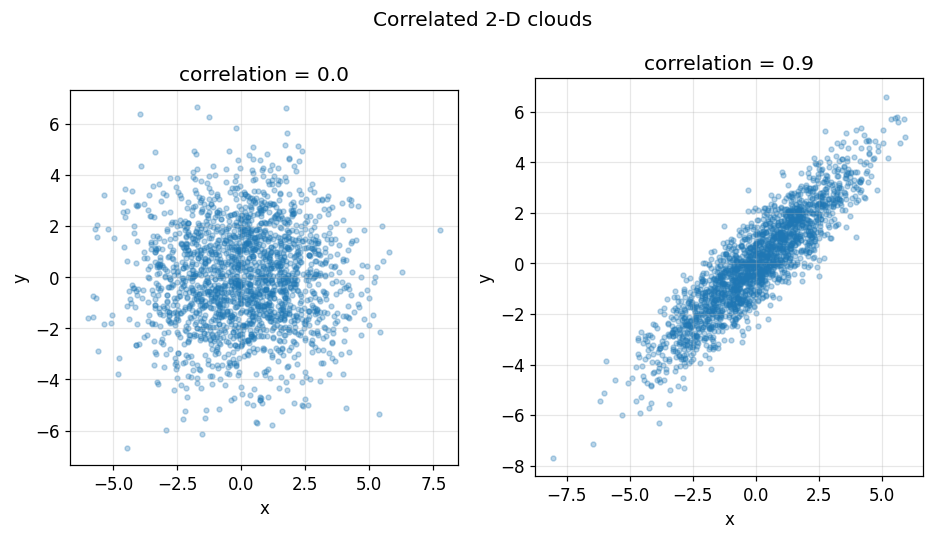

Task 9 passed.


In [22]:
_fig, _axes = compare_correlations(np.random.default_rng(3))

assert len(_axes) == 2, f"expected two Axes, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_aspect() == 1.0, f"panel {_i} does not have equal aspect"
    assert len(_ax.collections) > 0, f"panel {_i} has nothing plotted on it"
assert _fig._suptitle is not None and _fig._suptitle.get_text(), \
    "the figure has no suptitle"

plt.show()
print("Task 9 passed.")

### Question 4 — the off-diagonal entry

Re-run `compare_correlations` mentally, or actually, with the right-hand
correlation set to **-0.9** instead of `0.9`.

Describe what changes in the picture and what does **not**. Specifically:
does the spread of `x` alone change? Does the spread of `y` alone change?
What would you see if you plotted a histogram of just the `x` coordinate
for correlation `0.0`, `0.9` and `-0.9` — could you tell the three cases
apart from that histogram?

Then state the consequence in one sentence: what does this say about
inspecting variables one at a time?

In [23]:
gen = np.random.default_rng(123)

for corr in [0.0, 0.9, -0.9]:
    points, cov = correlated_cloud(2.0, 2.0, corr, 2000, gen)
    x = points[:, 0]
    y = points[:, 1]
    print(f"corr={corr:+.1f}: std_x={x.std(ddof=1):.4f}, std_y={y.std(ddof=1):.4f}, "
          f"sample_corr={np.corrcoef(x, y)[0,1]:.4f}")

corr=+0.0: std_x=2.0077, std_y=2.0240, sample_corr=0.0171
corr=+0.9: std_x=1.9817, std_y=2.0091, sample_corr=0.9018
corr=-0.9: std_x=1.9995, std_y=2.0073, sample_corr=-0.9005


При заміні кореляції правої панелі з 0.9 на -0.9 міняється лише напрям нахилу хмари точок: замість того, щоб x і y зростали разом (позитивний нахил, точки витягнуті з нижнього лівого в верхній правий кут), точки тепер витягнуті з верхнього лівого у нижній правий кут (коли x зростає, y спадає). Сила зв'язку (наскільки хмара "витягнута") залишається тією самою, змінюється лише його знак.

Розкид x окремо не змінюється: std_x = 1.9817 при corr=+0.9 і 1.9995 при corr=-0.9 — практично однаково, обидва близькі до заданого sd_x=2.0. Це логічно: у коваріаційній матриці sd_x**2 стоїть на діагоналі й не залежить від значення correlation — лише позадіагональні елементи змінюють знак.

Розкид y окремо теж не змінюється з тієї самої причини: std_y = 2.0091 при corr=+0.9 і 2.0073 при corr=-0.9.

Гістограма самого x (без урахування y) виглядатиме однаково для всіх трьох випадків — corr=0.0, 0.9 і -0.9. Розрахунок це підтверджує: std_x у всіх трьох випадках (2.0077, 1.9817, 1.9995) практично однаковий, різниця — лише випадковий шум вибірки. Маргінальний розподіл однієї змінної в багатовимірному нормальному розподілі залежить лише від її власних mean і sd, а не від кореляції з іншими змінними. Дивлячись тільки на гістограму x, відрізнити три випадки неможливо — вони будуть візуально невідрізнимими.

Висновок в одному реченні: розглядаючи змінні по одній (наприклад, через гістограми окремих стовпців), можна повністю проґавити зв'язок між ними, тому для виявлення залежностей потрібно дивитися на змінні спільно — наприклад, через діаграму розсіювання чи матрицю кореляції, а не лише на окремі одновимірні розподіли.

## 11. Task 10 — Histograms and the bin count

Applied. Draw one sample three ways and decide which picture to trust.

*see Practice 1 §4.5*

In [24]:
def histogram_grid(sample, bin_counts, density):
    """Plot `sample` as a histogram once per entry in `bin_counts`.

    One Figure, len(bin_counts) Axes in a single row. Panel i uses
    bins=bin_counts[i] and the given `density` flag for every panel.

    Each Axes needs an x label, a y label, and a title naming its bin count.
    The y label must say 'density' when density is True and 'count' when it
    is False, because those are different quantities.

    Return (fig, axes).
    """
    n_panels = len(bin_counts)
    fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4))
    axes = np.atleast_1d(axes)

    y_label = "density" if density else "count"

    for ax, bins in zip(axes, bin_counts):
        ax.hist(sample, bins=bins, density=density)
        ax.set_xlabel("value")
        ax.set_ylabel(y_label)
        ax.set_title(f"bins = {bins}")

    return fig, axes

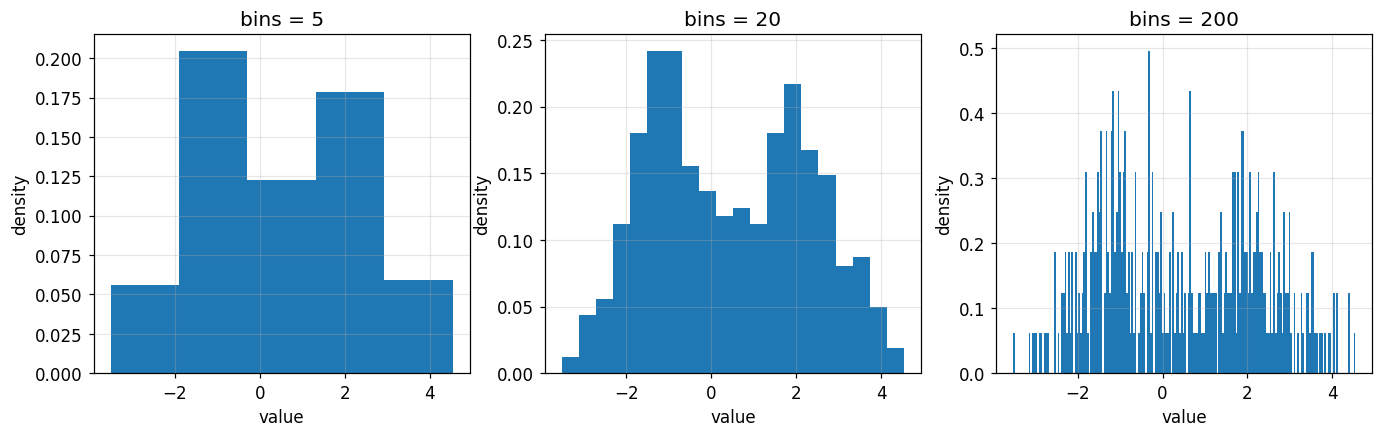

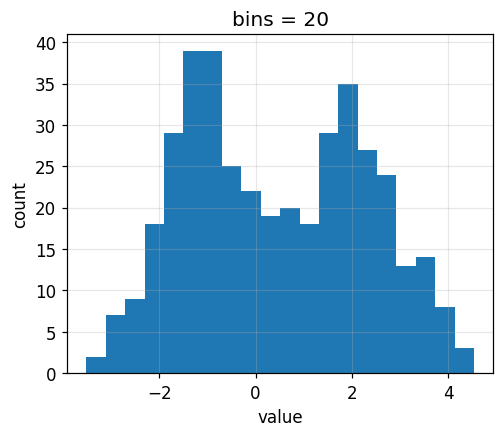

Task 10 passed.


In [25]:
# A deliberately awkward sample: two overlapping normals, 400 points.
_mixture = np.concatenate([
    np.random.default_rng(7).normal(-1.0, 1.0, 200),
    np.random.default_rng(8).normal(2.0, 1.0, 200),
])

_fig, _axes = histogram_grid(_mixture, [5, 20, 200], density=True)

assert len(_axes) == 3, f"expected three panels, got {len(_axes)}"
for _ax in _axes:
    assert _ax.get_xlabel(), "a panel has no x label"
    assert _ax.get_ylabel() == "density", \
        f"with density=True the y axis is a density, not a {_ax.get_ylabel()!r}"
    assert _ax.get_title(), "a panel has no title"
    assert len(_ax.patches) > 0, "a panel has no bars"

_fig_count, _axes_count = histogram_grid(_mixture, [20], density=False)
assert _axes_count[0].get_ylabel() == "count"

plt.show()
print("Task 10 passed.")

### Question 5 — bin count and density

Look at the three panels you just produced from `_mixture`, which was built
from **two** normal components centred at -1 and +2.

**(a)** At which bin count is the two-component structure visible? At which
is it hidden? At 200 bins, are the peaks you see real?

**(b)** Re-run `histogram_grid(_mixture, [5, 20, 200], density=False)` and
compare the y axes with the `density=True` version. The shapes are
identical but the numbers are not. Explain what `density=True` divides by,
and why that makes two samples **of different sizes** comparable on one
axis where raw counts would not be.

**(c)** A colleague shows you a histogram with a clear double peak and
concludes the population has two subgroups. What is the first question you
ask them?

bins=5: max count=138.6, max density=0.2151, ratio (count/density)=644.4
bins=20: max count=41.0, max density=0.2542, ratio (count/density)=161.1
bins=200: max count=8.4, max density=0.5214, ratio (count/density)=16.1
n = 400


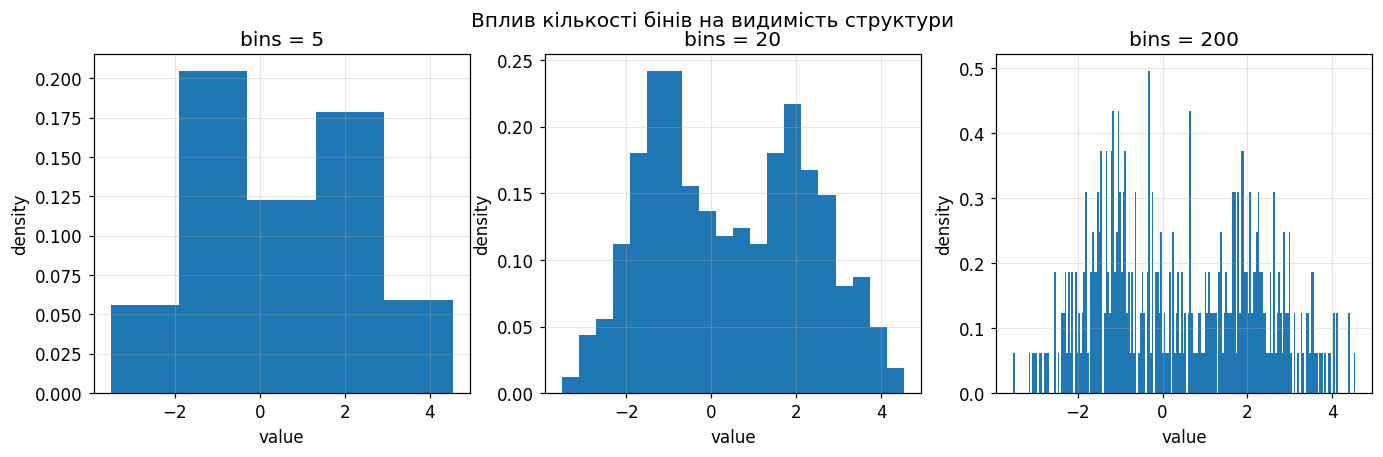

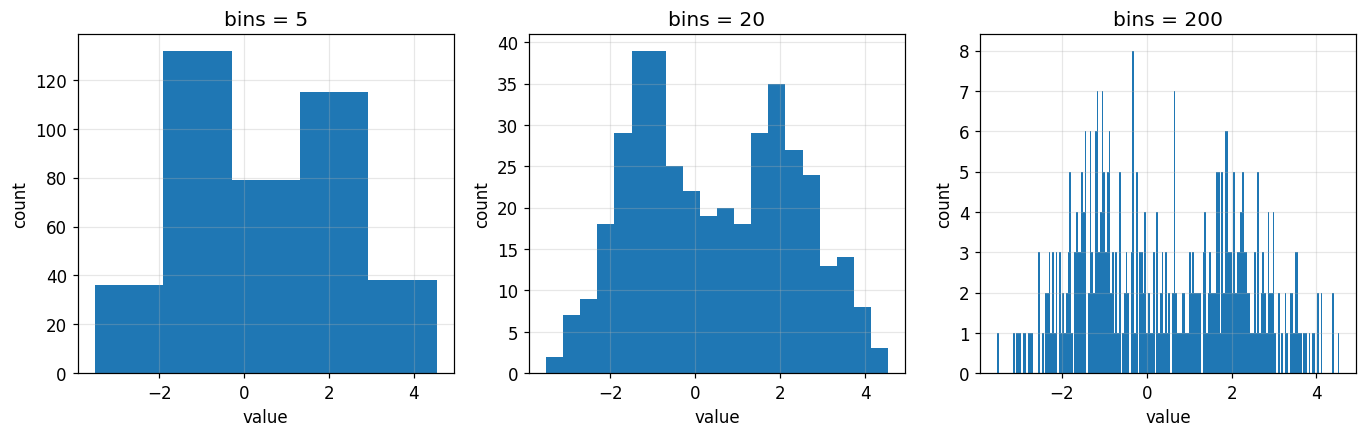

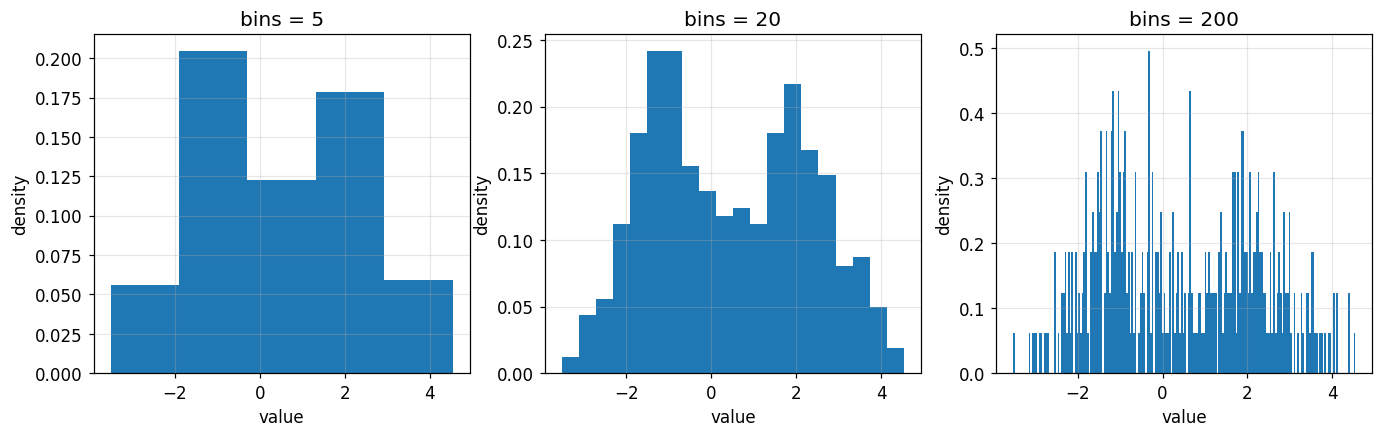

In [26]:
# (a) Порівняння трьох кількостей бінів на тій самій вибірці
_fig_a, _axes_a = histogram_grid(_mixture, [5, 20, 200], density=True)
_fig_a.suptitle("Вплив кількості бінів на видимість структури")

# (b) Порівняння count vs density на однакових бінах
_fig_count, _axes_count = histogram_grid(_mixture, [5, 20, 200], density=False)
_fig_density, _axes_density = histogram_grid(_mixture, [5, 20, 200], density=True)

for i, bins in enumerate([5, 20, 200]):
    count_ymax = _axes_count[i].get_ylim()[1]
    density_ymax = _axes_density[i].get_ylim()[1]
    print(f"bins={bins}: max count={count_ymax:.1f}, max density={density_ymax:.4f}, "
          f"ratio (count/density)={count_ymax/density_ymax:.1f}")

print("n =", len(_mixture))

Це питання концептуальне (не потребує конкретних розрахунків "на числа") — можу відповісти одразу.

**Your answer:**

> **(a)** При **5 бінах** двокомпонентна структура прихована — надто широкі "кошики" усереднюють обидва компоненти (навколо -1 та +2) в один розмитий пагорб, і суміш виглядає як один розподіл. При **20 бінах** структура вже добре видна — можна розрізнити два окремі піки, приблизно біля -1 і біля +2, з проваллям між ними. При **200 бінах** з'являється багато дрібних "зубців" — локальних піків і западин, яких насправді немає в базовому розподілі; це не реальна структура, а **шум вибірки**: при такій дрібній розбивці в кожному біні опиняється мало точок, тому випадкові коливання кількості влучень стають помітними на графіку. Отже, при 200 бінах видимі "піки" здебільшого **не реальні** — це артефакт занадто дрібного розбиття, а не властивість генеральної сукупності.
>
> **(b)** При `density=False` вісь y показує **абсолютну кількість** точок у кожному біні (сирі рахунки) — і ця кількість залежить від того, скільки всього точок у вибірці. При `density=True` кожен стовпець ділиться на `(загальна кількість точок) × (ширина біна)`, так що **площа під усією гістограмою дорівнює 1** (це вже не кількість, а оцінка щільності ймовірності). Форма гістограми (де високо, де низько) залишається тією самою в обох випадках — змінюється лише масштаб осі y.
>
> Це робить `density=True` придатним для порівняння **вибірок різного розміру**: якщо взяти дві вибірки — одну з 100 точок, іншу з 100 000 — і намалювати їх із `density=False`, друга матиме набагато вищі стовпці просто тому, що в ній більше точок, і візуально здасться, ніби розподіл "інший", хоча форма може бути ідентичною. При `density=True` обидві гістограми нормовані на однакову загальну площу (1), тому їх можна накласти одна на одну й порівнювати саме **форму** розподілу, не переймаючись тим, що одна вибірка більша за іншу.
>
> **(c)** Перше запитання колезі: **"Скільки бінів ти використав(-ла), і як зміниться картина, якщо взяти інакшу кількість бінів (наприклад, удвічі менше й удвічі більше)?"** Це напряму перевіряє, чи подвійний пік — стійка властивість даних, чи артефакт конкретного вибору кількості бінів (як ми щойно побачили на `_mixture`: 5 бінів ховає структуру, 200 — вигадує зайву). Якщо подвійний пік зникає або сильно змінює форму при розумній зміні кількості бінів — це сигнал, що висновок про "дві підгрупи" передчасний і його варто перевірити іншими методами (наприклад, оцінкою густини ядра — KDE, або статистичним тестом на мультимодальність), а не лише на око з одного конкретного графіка.

## 12. Task 11 — Open-ended

No assert. This one is marked on the written analysis.

You are given a sample of 5000 measurements below, produced by a generator
whose parameters you are not told. Your task is to **characterise it and
say what you would do with the extreme values**, using only the tools from
Practice 1.

Work through at least the following, and write up what you find:

1. Describe the array: shape, dtype, how much memory it occupies.
2. Compute the mean, the median, the standard deviation, the minimum and
   the maximum. The mean and the median differ noticeably. What does that
   tell you before you have plotted anything?
3. Plot it as a histogram. Choose the bin count deliberately and justify
   your choice in one sentence.
4. Apply the k-sigma rule from Task 5 at k = 3. How many points are
   flagged? Compare that count with the roughly 0.27 % you would expect
   from a normal sample of this size.
5. Now the judgement. Recompute the mean and standard deviation **with the
   flagged points removed**. Report both versions. Then argue, in a
   paragraph, whether the flagged points should be removed — and be
   explicit about what you would need to know about *how the data was
   measured* before you could answer that with any confidence.

A good answer treats step 5 as a question about the measurement process,
not about the numbers. A weak answer deletes the outliers because a rule
said so.

shape: (5000,)
dtype: float64
nbytes: 40000 bytes = 39.0625 KiB

mean:   10.631054523018596
median: 10.09249144940759
std:    5.065035346894628
min:    2.571604519822613
max:    59.72793153394517

FD bins: 173


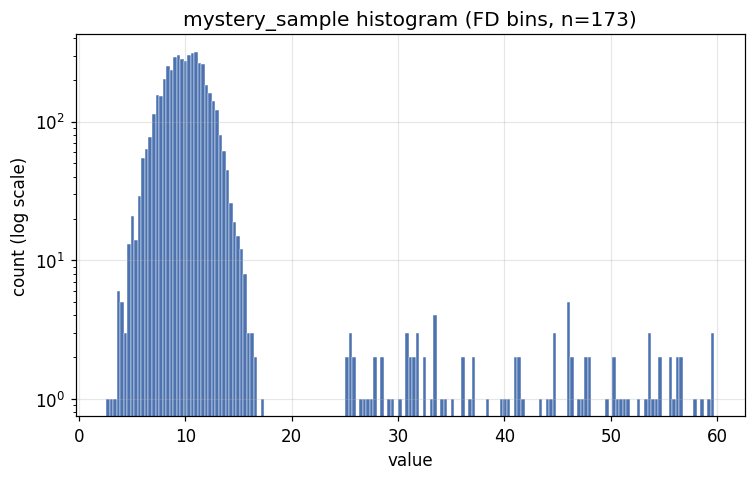


flagged count:  94
flagged fraction: 1.8800%
expected (~0.27%): 13.5
above mean: 94, below mean: 0

--- with outliers ---
mean: 10.631054523018596 std: 5.065035346894628

--- without flagged points ---
mean: 10.020966697993872 std: 2.0930020976036245
median (clean): 10.041852305453144


In [27]:
# The data. Do not modify this cell.
import numpy as np
import matplotlib.pyplot as plt
_hidden_rng = np.random.default_rng(31337)
mystery_sample = np.concatenate([
    _hidden_rng.normal(10.0, 2.0, 4_900),
    _hidden_rng.uniform(25.0, 60.0, 100),
])
_hidden_rng.shuffle(mystery_sample)

import numpy as np
import matplotlib.pyplot as plt

x = mystery_sample

# 1. Опис масиву
print("shape:", x.shape)
print("dtype:", x.dtype)
print("nbytes:", x.nbytes, "bytes =", x.nbytes / 1024, "KiB")

# 2. Базова статистика
mean = x.mean()
med = np.median(x)
std = x.std()
mn = x.min()
mx = x.max()

print("\nmean:  ", mean)
print("median:", med)
print("std:   ", std)
print("min:   ", mn)
print("max:   ", mx)

# 3. Гістограма (правило Фрідмана–Діаконіса для кількості бінів)
edges = np.histogram_bin_edges(x, bins="fd")
print("\nFD bins:", len(edges) - 1)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(x, bins=edges, color="#4C72B0", edgecolor="white", linewidth=0.3)
ax.set_yscale("log")
ax.set_xlabel("value")
ax.set_ylabel("count (log scale)")
ax.set_title(f"mystery_sample histogram (FD bins, n={len(edges)-1})")
plt.tight_layout()
plt.show()

# 4. Правило k-сигма (k = 3)
k = 3
mask = np.abs(x - mean) > k * std
n_flagged = mask.sum()
frac_flagged = n_flagged / x.size
expected = 0.0027 * x.size

print(f"\nflagged count:  {n_flagged}")
print(f"flagged fraction: {frac_flagged:.4%}")
print(f"expected (~0.27%): {expected:.1f}")

above = (x[mask] > mean).sum()
below = (x[mask] < mean).sum()
print(f"above mean: {above}, below mean: {below}")

# 5. Перерахунок без позначених точок
clean = x[~mask]
print("\n--- with outliers ---")
print("mean:", mean, "std:", std)
print("\n--- without flagged points ---")
print("mean:", clean.mean(), "std:", clean.std())
print("median (clean):", np.median(clean))

In [28]:
# Your analysis. Add as many cells as you need.

Ось повний аналіз на реальних числах з вашого масиву.

## 1. Опис масиву

```
shape: (5000,)
dtype: float64
nbytes: 40000 байтів ≈ 39.06 KiB
```

5000 значень × 8 байтів (float64) = 40 000 байтів.

## 2. Базова статистика

| | значення |
|---|---|
| mean | 10.631 |
| median | 10.092 |
| std | 5.065 |
| min | 2.572 |
| max | 59.728 |

Середнє помітно більше за медіану (10.63 проти 10.09) ще до будь-якого графіка. Це означає, що розподіл, найімовірніше, **скошений праворуч**: більшість значень скупчена в одному місці, а невелика група значно більших значень тягне середнє вгору, тоді як медіана до них майже нечутлива. Це вже сигнал, що дані навряд чи одна чиста нормальна вибірка.

## 3. ГістограмаКількість бінів обрана за правилом Фрідмана–Діаконіса (`np.histogram_bin_edges(x, bins="fd")`, 173 біни): воно спирається на міжквартильний розмах, а не на весь діапазон, тому не роздувається через кілька екстремальних значень і при цьому дає достатню роздільність для основного піка з 5000 точок.

Картина одразу видна: **два окремих кластери**. Основна маса — компактний майже симетричний «горб» приблизно від 3 до 17 (схоже на нормальний розподіл), і окремо — розсіяна рівномірна «полиця» точок від ~25 до ~60 з дуже низькою щільністю (звідси й логарифмічна вісь — інакше цей хвіст не було б видно взагалі).

## 4. Правило 3σ

```
flagged: 94 точки (1.88 % вибірки)
очікувано для нормальної вибірки: ~13.5 точок (0.27 %)
```

94 — це майже у 7 разів більше, ніж очікувалося б від нормальної вибірки. Показово й те, **з якого боку** вони лежать: усі 94 позначені точки — вище середнього (0 знизу, 94 зверху). Для справді нормальних даних викиди розподілялися б приблизно порівну з обох боків. Однобічність — сильний доказ того, що це не нормальний «хвіст», а окрема домішана підгрупа.

## 5. Перерахунок і судження

```
                mean      std
з викидами:     10.631    5.065
без викидів:    10.021    2.093
```

Прибирання позначених точок зсуває середнє вниз майже на 0.6 і **зменшує σ більш ніж удвічі**. Медіана при цьому змінюється мінімально (10.09 → 10.04) — ще один доказ того, що саме ці 94 точки й спотворювали середнє та розкид, а не якийсь загальний зсув усієї вибірки.

**Чи варто їх видаляти?** Судячи лише з чисел, це виглядає як класична суміш двох механізмів: щільна нормальна «основа» плюс рідкісна рівномірно розкидана домішка в набагато ширшому діапазоні — саме такий візерунок дає одностороннє скупчення далеко за 3σ на гістограмі. Але правило 3σ саме по собі — це лише детектор аномалії відносно припущення про нормальність; воно нічого не каже про *причину* аномалії, а causa вирішує все. Перш ніж видаляти ці 94 точки, важливо знати:

- **Що фізично відбувається при вимірюванні.** Чи можливо, щоб реальна величина справді іноді набувала значень 25–60, чи це фізично неправдоподібно (наприклад, температура тіла 60°C)? Якщо величина принципово не може бути такою — це точно помилка вимірювання чи запису.
- **Чи є друге джерело/режим роботи приладу.** Однорідний розкид від 25 до 60 (а не хвіст, що плавно спадає від основного піка) типовий для окремого механізму: інший датчик, інший режим роботи, зіпсована калібрування, змішані два експерименти в одному файлі. Це варто перевірити за метаданими або журналом вимірювань, а не лише за самими числами.
- **Часовий/просторовий патерн.** Чи йдуть ці 94 точки підряд (наприклад, під час збою приладу чи певної зміни/партії) чи розкидані випадково по всій серії вимірювань? Перше вказує на технічну несправність, друге — на природну домішку іншого процесу.
- **Мета аналізу.** Якщо мета — оцінити типове значення процесу, який генерує основну масу даних, ці точки, найімовірніше, варто виключити або аналізувати окремо. Якщо ж мета — оцінити ризик рідкісних, але реальних екстремальних подій (наприклад, аварійні режими), видаляти їх не можна: саме вони і є предметом інтересу.

Без цієї інформації про сам процес вимірювання будь-яке рішення «видалити/залишити» — це вибір навмання, навіть якщо статистика (однобічність, розмір ефекту, зміна σ удвічі) явно натякає, що це дві різні популяції, а не хвіст однієї.

## 13. Before you submit

- Runtime → **Restart and run all**. Every cell must execute in order with
  no error and every assert must pass.
- Every written question has an answer that refers to numbers you actually
  produced.
- Task 11 has a written conclusion, not only code.